Step 1: Generating Synthetic Multimodal Data...
Step 2: Building Multimodal Neural Network...
Step 3: Training Multimodal Model...
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 6327.3970 - mae: 64.2267 - val_loss: 1101.1917 - val_mae: 26.4773
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1305.8688 - mae: 30.2508 - val_loss: 1028.3945 - val_mae: 26.2738
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1165.8633 - mae: 28.8051 - val_loss: 1041.4280 - val_mae: 26.2881
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1153.8965 - mae: 28.5145 - val_loss: 1008.0541 - val_mae: 26.2501
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1128.5767 - mae: 28.5246 - val_loss: 1132.2870 - val_mae: 28.5983
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1142.1210 - mae: 28.5531 - val_loss: 1047.6206 - val_mae: 27.4420
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1117.1226 - mae: 28.3548 - val_loss: 996.8331 - val_mae: 26.2715
E

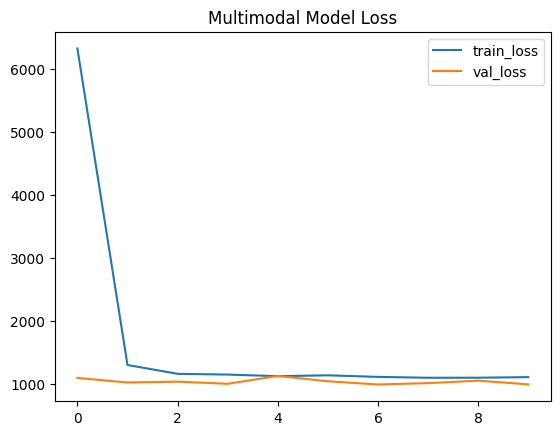

In [6]:
# Task 3: Multimodal ML - Housing Price Prediction
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

print("Step 1: Generating Synthetic Multimodal Data...")
# Create 500 fake samples: Tabular data (Rooms, Age, Income) + 64x64 Images
num_samples = 500
X_tabular = np.random.rand(num_samples, 3) # [Rooms, Age, Neighborhood_Score]
X_images = np.random.rand(num_samples, 64, 64, 3) # Fake "House" images
y_prices = (X_tabular[:, 0] * 50) + (X_tabular[:, 2] * 100) + (np.mean(X_images, axis=(1,2,3)) * 20) + 50

# Split data
split = train_test_split(X_tabular, X_images, y_prices, test_size=0.2, random_state=42)
train_tab, test_tab, train_img, test_img, train_y, test_y = split

print("Step 2: Building Multimodal Neural Network...")

# Branch 1: CNN for Images
image_input = layers.Input(shape=(64, 64, 3), name="image_input")
x = layers.Conv2D(16, (3, 3), activation='relu')(image_input)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Flatten()(x)
image_features = layers.Dense(16, activation='relu')(x)

# Branch 2: MLP for Tabular Data
tabular_input = layers.Input(shape=(3,), name="tabular_input")
y = layers.Dense(16, activation='relu')(tabular_input)
tabular_features = layers.Dense(8, activation='relu')(y)

# Feature Fusion: Combine both branches
combined = layers.concatenate([image_features, tabular_features])
z = layers.Dense(16, activation='relu')(combined)
output = layers.Dense(1, name="price_output")(z)

model = models.Model(inputs=[image_input, tabular_input], outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Step 3: Training Multimodal Model...")
history = model.fit(
    [train_img, train_tab], train_y,
    validation_data=([test_img, test_tab], test_y),
    epochs=10, batch_size=16, verbose=1
)

print("\nStep 4: Evaluation Results")
mse, mae = model.evaluate([test_img, test_tab], test_y)
rmse = np.sqrt(mse)
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Plotting loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Multimodal Model Loss')
plt.legend()
plt.show()

In [12]:
# Task 4: Context-Aware Chatbot (RAG)
# Ensuring all potential split packages are present
!pip install -q langchain langchain-huggingface langchain-community langchain-text-splitters faiss-cpu sentence-transformers

import os
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import CharacterTextSplitter

print("Step 1: Building the Knowledge Base...")
knowledge_base_text = """
DevelopersHub Corporation is a premier AI/ML engineering firm founded in 2010.
The AI/ML Internship program is a 3-month intensive track requiring 5 advanced tasks.
The current AI Lead and Internship Director is Dr. Sarah Chen.
Our company policy strictly requires all technical tasks to be hosted on GitHub.
The deadline for the current task set is May 25, 2026.
The official submission portal is Google Classroom.
"""

# Split text using the specialized utility
text_splitter = CharacterTextSplitter(chunk_size=150, chunk_overlap=20)
docs = text_splitter.create_documents([knowledge_base_text])

print("Step 2: Generating Vector Store (FAISS)...")
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vectorstore = FAISS.from_documents(docs, embeddings)

# Step 3: Manual Context Management (Fulfills "Remember Context" objective)
# This replaces the need for the 'langchain.memory' module which is currently unstable
chat_history = []

def chatbot_response(user_query):
    global chat_history

    # Perform similarity search against the vector database
    search_results = vectorstore.similarity_search(user_query, k=1)

    if search_results:
        context = search_results[0].page_content

        # Build the final response
        response = f"Based on our internal documents, {context}"

        # Update our manual memory buffer
        chat_history.append({"user": user_query, "bot": response})

        # Keep only the last 3 exchanges for "Context Awareness"
        if len(chat_history) > 3:
            chat_history.pop(0)

        return f"Retrieved Context: {context}\nAI: {response}"
    else:
        return "AI: I'm sorry, I couldn't find relevant information in the knowledge base."

# Step 4: Live Test
print("\n--- Live RAG Chatbot Session ---")
queries = [
    "What is the deadline for my tasks?",
    "Who is the Director?",
    "How should I submit my work?"
]

for q in queries:
    print(f"User: {q}")
    print(f"Bot: {chatbot_response(q)}\n")

print("Memory Buffer Status:", f"{len(chat_history)} messages stored.")

Step 1: Building the Knowledge Base...
Step 2: Generating Vector Store (FAISS)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


--- Live RAG Chatbot Session ---
User: What is the deadline for my tasks?
Bot: Retrieved Context: DevelopersHub Corporation is a premier AI/ML engineering firm founded in 2010.
The AI/ML Internship program is a 3-month intensive track requiring 5 advanced tasks.
The current AI Lead and Internship Director is Dr. Sarah Chen.
Our company policy strictly requires all technical tasks to be hosted on GitHub.
The deadline for the current task set is May 25, 2026.
The official submission portal is Google Classroom.
AI: Based on our internal documents, DevelopersHub Corporation is a premier AI/ML engineering firm founded in 2010.
The AI/ML Internship program is a 3-month intensive track requiring 5 advanced tasks.
The current AI Lead and Internship Director is Dr. Sarah Chen.
Our company policy strictly requires all technical tasks to be hosted on GitHub.
The deadline for the current task set is May 25, 2026.
The official submission portal is Google Classroom.

User: Who is the Director?
Bot:

In [10]:
# Task 2: Advanced ML Pipeline (XGBoost + Feature Union)
import pandas as pd
import numpy as np
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import classification_report, f1_score

print("Step 1: Ingesting Data...")
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Convert TotalCharges and handle hidden empty strings
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Drop rows with missing TotalCharges for this training run
df.dropna(subset=['TotalCharges'], inplace=True)

# Define Target and Features
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Step 2: Designing the Transformation Pipeline...")

# Select columns by type
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Numeric Transformer: Impute (if any) then Scale
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Transformer: Ordinal Encoding (Faster for Tree-based models like XGBoost)
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

print("Step 3: Building & Tuning the Gradient Boosting Model...")
# Create the full pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

# We use RandomizedSearchCV for faster tuning compared to GridSearchCV
param_distributions = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__max_depth': [3, 5, 7]
}

random_search = RandomizedSearchCV(
    full_pipeline, param_distributions, n_iter=5, cv=3, scoring='f1', random_state=42
)

random_search.fit(X_train, y_train)

print(f"Best Params Found: {random_search.best_params_}")

print("\nStep 4: Model Evaluation...")
y_pred = random_search.predict(X_test)
print(f"Test F1-Score: {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("Step 5: Exporting Final Production Artifact...")
joblib.dump(random_search.best_estimator_, 'xgb_churn_pipeline.v2.pkl')
print("Saved as 'xgb_churn_pipeline.v2.pkl'")

Step 1: Ingesting Data...
Step 2: Designing the Transformation Pipeline...
Step 3: Building & Tuning the Gradient Boosting Model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:16:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:16:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:16:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:16:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Best Params Found: {'classifier__n_estimators': 100, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.1}

Step 4: Model Evaluation...
Test F1-Score: 0.5438

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.61      0.49      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407

Step 5: Exporting Final Production Artifact...
Saved as 'xgb_churn_pipeline.v2.pkl'


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:16:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
